# ECC Media Cryptosystem
### Using Helper Functions from Local Modules

This notebook imports logic directly from `KeyGeneration.py`, `Encrypt.py`, and `Decrypt.py` to encrypt and decrypt media files (JPEG, MP3, MP4).

In [26]:
from sage.all import *
import secrets, time, os

# Direct imports from your uploaded files
from KeyGeneration import generate_keypair
from Encrypt import parse_point, compute_chunk_size, map_chars_to_point, encrypt_blocks
from Decrypt import map_point_to_chars, parse_point

print("Modules imported successfully.")

Modules imported successfully.


## 1. System Initialization
We use the `generate_keypair` function from `KeyGeneration.py` using Mode 2 (Predefined curves) to set up our environment.

In [27]:
# Initialize system using Mode 2 (secp256k1)
VERBOSE = False
params = generate_keypair(2, ["secp256k1"])

E = params['curve']
G = params['generator']
private_key = params['private_key']
public_key = params['public_key']
q = params['prime_order']

print(f"Curve: {E}")
print(f"Public Key (P): {public_key}")

Curve: Elliptic Curve defined by y^2 = x^3 + 7 over Finite Field of size 115792089237316195423570985008687907853269984665640564039457584007908834671663
Public Key (P): (52707468041269465130386404278243979273984833960869854933456159872809569524636 : 27450338605490502709029641930842417349182018658897050840527754116273727196908 : 1)


## 2. Media Encryption & Decryption
We adapt the helper functions to work with raw byte streams from media files.

In [28]:
def encrypt_media_to_file(file_path, E, G, public_key):
    """
    Encrypts a media file using Encrypt.encrypt_blocks and saves to a JSON file.
    """
    if not os.path.exists(file_path):
        print(f"File {file_path} not found.")
        return

    # 1. Read binary data
    with open(file_path, 'rb') as f:
        raw_data = f.read()
    
    print(f"--- Starting Encryption for {file_path} ---")
    t0 = time.time()
    
    # 2. Determine chunk size and map binary data to curve points
    # We use your helpers from Encrypt.py
    chunk_size = compute_chunk_size(E)
    M_blocks = []
    
    for i in range(0, len(raw_data), chunk_size):
        chunk = raw_data[i : i + chunk_size]
        # map_chars_to_point handles the lifting and 8-bit padding
        M = map_chars_to_point(chunk, E)
        M_blocks.append(M)
    
    # 3. Use your script's built-in block encryption function
    # This generates C1 (ephemeral) and the list of C2 points
    ciphertext_bundle = encrypt_blocks(M_blocks, G, public_key)
    
    # 4. Save the encrypted bundle to a temporary JSON file
    # We also store the original length to make decryption easier later
    ciphertext_bundle['original_length'] = len(raw_data)
    ciphertext_bundle['file_name'] = file_path
    
    output_filename = f"encrypted_{file_path}.json"
    with open(output_filename, 'w') as f_out:
        json.dump(ciphertext_bundle, f_out, indent=2)

    ciphertext_size_bytes = os.path.getsize(output_filename)
    
    print(f"Encryption finished in {time.time() - t0:.2f}s")
    print(f"Ciphertext bundle saved to: {output_filename}\n")
    print(f"Ciphertext Size: {ciphertext_size_bytes / 1024:.2f} KB")

In [29]:
def decrypt_media_from_bundle(json_path, E, private_key):
    """
    Uses ECC Decryption to recover encrypted media data.
    """
    if not os.path.exists(json_path):
        print(f"Error: {json_path} not found.")
        return

    print(f"--- Decrypting Media Bundle: {json_path} ---")
    t0 = time.time()

    # Load the ciphertext bundle
    with open(json_path, 'r') as f_in:
        bundle = json.load(f_in)
    
    C1_str = bundle['C1']
    C2_entries = bundle['ciphertexts']
    original_len = bundle['original_length']
    original_filename = bundle.get('file_name', 'recovered_file')
    
    C1 = parse_point(C1_str, E)
    skC1 = private_key * C1
    
    recovered_byte_stream = bytearray()
    
    for entry in C2_entries:
        C2 = parse_point(entry['C2'], E)
        
        M = C2 - skC1
        
        chunk_bytes = map_point_to_chars(M)
        
        # Binary Consistency Check:
        # Since map_point_to_chars uses 'while X > 0', it may return fewer 
        # bytes if the chunk had trailing zeros. We pad to the expected chunk size
        # to maintain binary alignment (except for potentially the last block).
        expected_chunk_size = (E.base_field().order().nbits() - 9) // 8
        if len(chunk_bytes) < expected_chunk_size:
            chunk_bytes = chunk_bytes + b'\x00' * (expected_chunk_size - len(chunk_bytes))
            
        recovered_byte_stream.extend(chunk_bytes)
    
    # Trimming to original_length ensures the file isn't corrupted by trailing padding
    final_media_data = bytes(recovered_byte_stream[:original_len])
    
    output_name = f"recovered_{original_filename}"
    with open(output_name, 'wb') as f_out:
        f_out.write(final_media_data)
        
    print(f"Decryption successful in {time.time() - t0:.2f}s")
    print(f"Original Size: {original_len} bytes")
    print(f"Saved as: {output_name}\n")
    print("-" * 45)

In [10]:
media_files = ["image.jpeg", "audio.mp3", "video.mp4"]
for f in media_files:
    process_media_file(f, E, G, public_key, private_key)

File image.jpeg not found.
File audio.mp3 not found.
File video.mp4 not found.


=== Original Image ===


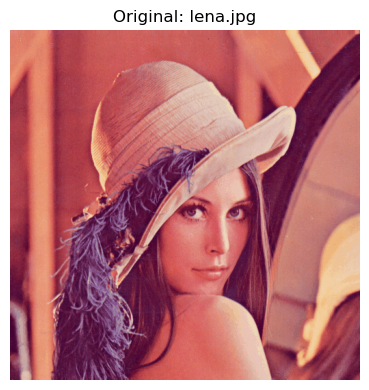

File: lena.jpg  |  Size: 222.01 KB  |  Shape: (512, 512, 4)



In [30]:
import os
import json
import time
import IPython.display as ipd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

IMAGE_PATH = "lena.jpg"

print("=== Original Image ===")
img = mpimg.imread(IMAGE_PATH)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Original: {IMAGE_PATH}")
plt.tight_layout()
plt.show()

file_size_kb = os.path.getsize(IMAGE_PATH) / 1024
print(f"File: {IMAGE_PATH}  |  Size: {file_size_kb:.2f} KB  |  Shape: {img.shape}\n")

In [31]:
print("=== Encrypting Image ===")

encrypt_media_to_file(IMAGE_PATH, E, G, public_key)

=== Encrypting Image ===
--- Starting Encryption for lena.jpg ---
Encryption finished in 3.39s
Ciphertext bundle saved to: encrypted_lena.jpg.json

Ciphertext Size: 1414.33 KB


In [32]:
ENCRYPTED_IMAGE = "encrypted_lena.jpg.json"

decrypt_media_from_bundle(ENCRYPTED_IMAGE, E, private_key)

--- Decrypting Media Bundle: encrypted_lena.jpg.json ---
Decryption successful in 0.57s
Original Size: 227335 bytes
Saved as: recovered_lena.jpg

---------------------------------------------


In [ ]:
RECOVERED_PATH = "recovered

img = mpimg.imread(IMAGE_PATH)
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Original: {IMAGE_PATH}")
plt.tight_layout()
plt.show()

file_size_kb = os.path.getsize(IMAGE_PATH) / 1024
print(f"File: {IMAGE_PATH}  |  Size: {file_size_kb:.2f} KB  |  Shape: {img.shape}\n")